In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("/Users/samad/Documents/NCAIR/DSB/DSB_Assignment_3/Housing.csv")
print(df.head())
print("\nTotal rows:", len(df))

df

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Total rows: 545


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
df = df.drop(columns=['mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning'])
df

,price,area,bedrooms,bathrooms,stories,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,2,yes,furnished
1,12250000,8960,4,4,4,3,no,furnished
2,12250000,9960,3,2,2,2,yes,semi-furnished
3,12215000,7500,4,2,2,3,yes,furnished
4,11410000,7420,4,1,2,2,no,furnished
...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,no,unfurnished
541,1767150,2400,3,1,1,0,no,semi-furnished
542,1750000,3620,2,1,1,0,no,unfurnished
543,1750000,2910,3,1,1,0,no,furnished


In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.535997  0.366494   0.517545  0.420712  0.384394
area       0.535997  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.366494  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.517545  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.420712  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.384394  0.352980  0.139270   0.177496  0.045547  1.000000


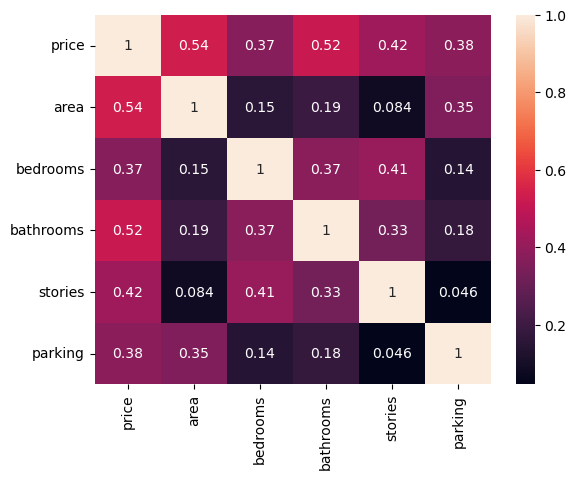

In [9]:
corr_matrix = df[['price', 'area', 'bedrooms', 'bathrooms', 'stories','parking']].corr()
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True)
plt.show()

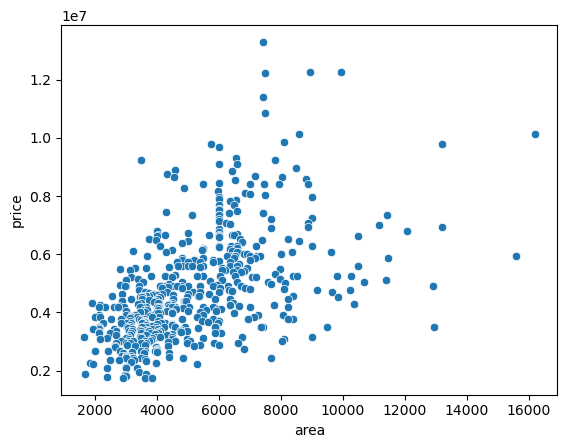

In [13]:
sns.scatterplot(x='area' ,y= 'price',data= df)
plt.show()

In [14]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'prefarea', 'furnishingstatus'],
      dtype='object')

In [18]:
X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y = df['price']

In [19]:
model = LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [3.31115495e+02 1.67809788e+05 1.13374016e+06 5.47939810e+05
 3.77596289e+05]
Intercept: -145734.4894558778


In [21]:
pred = model.predict([[1600, 3,3,2,2]])
print("Predicted Price:", pred[0])

Predicted Price: 6139772.351709657


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

In [25]:
np.random.seed(42)

n = 1000

# Generate features
hours = np.random.randint(1, 10, n)
attendance = np.random.randint(40, 100, n)

# Create probability of passing
prob_pass = (0.3 * hours + 0.05 * attendance) / 10

# Convert to binary outcome
pass_result = (prob_pass > 0.5).astype(int)

df = pd.DataFrame({
    "Hours_Studied": hours,
    "Attendance": attendance,
    "Pass": pass_result
})

print(df.head())
print("Total rows:", len(df))

   Hours_Studied  Attendance  Pass
0              7          63     1
1              4          62     0
2              8          98     1
3              5          47     0
4              7          93     1
Total rows: 1000


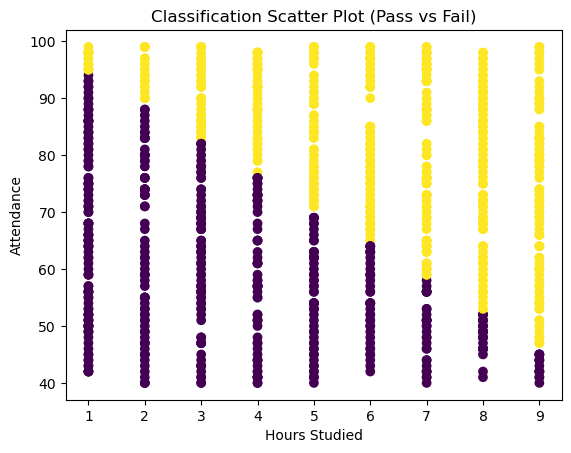

In [26]:
X = df[["Hours_Studied", "Attendance"]]
y = df["Pass"]

plt.scatter(
    X["Hours_Studied"], 
    X["Attendance"], 
    c=y  # color by class (0 or 1)
)

plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Classification Scatter Plot (Pass vs Fail)")

plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train)
print(X_train.shape)

In [ ]:
print(X_test)
print(X_test.shape)

In [ ]:
print(y_train)
print(y_train.shape)

In [ ]:
print(y_test)
print(y_test.shape)

In [ ]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))